In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [2]:
# 1. import database
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
#2. data cleaning
df_db_customer.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  10000 non-null  object 
 1   name        10000 non-null  object 
 2   country     9847 non-null   object 
 3   state       10000 non-null  object 
 4   gender      10000 non-null  object 
 5   dob         10000 non-null  object 
 6   interests   6419 non-null   object 
 7   pincode     9979 non-null   float64
dtypes: float64(1), object(7)
memory usage: 625.1+ KB


In [5]:
df_db_customer.head()


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN


In [6]:
# a. rename col- name
# b. drop columns- interest and pincode
# c. change data type- dob
# d. data standardization- gender
# e. fix missing values (using existing data) - country



In [7]:
# a. rename col- name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN
...,...,...,...,...,...,...,...,...
9995,2864-IVIPW,Ishan Nath Ahluwalia,India,Tripura,Male,1977-01-28 00:00:00,Music,795239.0
9996,6844-JGJIA,Arun Raj Mukherjee,India,Telangana,Male,2002-10-20 00:00:00,Movies,509255.0
9997,0343-BDKEW,Sneha Sinha,India,Uttarakhand,Female,2006-10-15 00:00:00,Movies,242610.0
9998,0944-BNXMB,Mira Krishnan,India,Madhya Pradesh,Female,2001-09-21 00:00:00,Drama,458982.0


In [8]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)  # using col name

In [9]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
...,...,...,...,...,...,...
9995,2864-IVIPW,Ishan Nath Ahluwalia,India,Tripura,Male,1977-01-28 00:00:00
9996,6844-JGJIA,Arun Raj Mukherjee,India,Telangana,Male,2002-10-20 00:00:00
9997,0343-BDKEW,Sneha Sinha,India,Uttarakhand,Female,2006-10-15 00:00:00
9998,0944-BNXMB,Mira Krishnan,India,Madhya Pradesh,Female,2001-09-21 00:00:00


In [10]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     10000 non-null  object
 1   customer_name  10000 non-null  object
 2   country        9847 non-null   object
 3   state          10000 non-null  object
 4   gender         10000 non-null  object
 5   dob            10000 non-null  object
dtypes: object(6)
memory usage: 468.9+ KB


In [11]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     10000 non-null  object        
 1   customer_name  10000 non-null  object        
 2   country        9847 non-null   object        
 3   state          10000 non-null  object        
 4   gender         10000 non-null  object        
 5   dob            10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 468.9+ KB


In [13]:
# d. data standardization - gender
# df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [14]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [15]:
# e. fix missing values - country

df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
96,9861-YTGXB,Tushar Kumar Khanna,None,Telangana,Male,1991-01-08
184,4979-FSLCI,Renu Kumari Dubey,None,Delhi,Female,1965-02-27
...,...,...,...,...,...,...
9615,7321-BTRMM,Mira Rani Dutt,None,Himachal Pradesh,Female,1984-11-16
9805,6816-VPZAY,Naveen Rao,None,Haryana,Male,1993-01-15
9808,0005-JWMDJ,Kritika Kumari Solanki,None,Jharkhand,Female,1965-02-24
9911,4458-MXIMU,Sandeep Devi Chandel,None,Kerala,Male,1982-06-12


In [16]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
...,...,...
9995,India,Tripura
9996,India,Telangana
9997,India,Uttarakhand
9998,India,Madhya Pradesh


In [17]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [18]:
df_db_customer[df_db_customer['country'].isna()] 

,customerid,customer_name,country,state,gender,dob


In [19]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [20]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [21]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               10000 non-null  object 
 1   subscription_start_date  10000 non-null  object 
 2   subscription_type        10000 non-null  object 
 3   renewal_date             10000 non-null  object 
 4   plan_type                10000 non-null  object 
 5   contract_type            10000 non-null  object 
 6   cancellation_date        2774 non-null   object 
 7   cancellation_reason      2774 non-null   object 
 8   monthly_charges          10000 non-null  float64
 9   cltv                     10000 non-null  int64  
 10  churn_score              10000 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 859.5+ KB


In [22]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               10000 non-null  object        
 1   subscription_start_date  10000 non-null  datetime64[ns]
 2   subscription_type        10000 non-null  object        
 3   renewal_date             10000 non-null  datetime64[ns]
 4   plan_type                10000 non-null  object        
 5   contract_type            10000 non-null  object        
 6   cancellation_date        2774 non-null   datetime64[ns]
 7   cancellation_reason      2774 non-null   object        
 8   monthly_charges          10000 non-null  float64       
 9   cltv                     10000 non-null  int64         
 10  churn_score              10000 non-null  int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 859.5+ KB


In [23]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,NaN,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,NaN,None


In [24]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      25000 non-null  object 
 1   complaint_date  25000 non-null  object 
 2   escalations     25000 non-null  object 
 3   csat_score      25000 non-null  int64  
 4   col_1           24991 non-null  float64
 5   comment         20806 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ MB


In [25]:
# drop columns
# col_1 is almost entirely null (useless) → dropping it
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [26]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      25000 non-null  object
 1   complaint_date  25000 non-null  object
 2   escalations     25000 non-null  object
 3   csat_score      25000 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 781.4+ KB


In [27]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      25000 non-null  object        
 1   complaint_date  25000 non-null  datetime64[ns]
 2   escalations     25000 non-null  object        
 3   csat_score      25000 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 781.4+ KB


In [28]:
df

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
24995,0343-BDKEW,2025-07-18,N,41
24996,0343-BDKEW,2026-06-11,N,21
24997,0944-BNXMB,2023-07-19,N,95
24998,5049-UGYWX,2024-10-18,N,45


In [32]:
df_db_subscription.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='object')

In [34]:
# Standardize spelling:
df_db_subscription['subscription_type'] = df_db_subscription['subscription_type'].replace({'Refferal': 'Referral'})

In [41]:
df_db_subscription['subscription_type'].unique().tolist()

['Referral', 'Paid', 'Organic']

In [ ]:
# 3.Feature Engineering and Data Analysis

In [46]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
# df = (df_db_subscription
#             .merge(df_db_customer, on = 'customerid', how= 'left')
#             .merge(df_db_support, on = 'customerid', how= 'left') )

In [47]:
df_db_subscription.shape

(10000, 12)

In [48]:
df.shape

(25995, 20)

In [49]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 10000
df_db_customer unique value: 10000
df_db_support unique value: 9005
df_db_support all value: 25000


In [50]:
df_db_support

,customerid,complaint_date,escalations,csat_score,is_escalated
0,0003-MKNFE,2024-08-28,N,60,0
1,0003-MKNFE,2024-08-28,Y,10,1
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,0
4,0013-SMEOE,2024-11-01,N,30,0
...,...,...,...,...,...
24995,0343-BDKEW,2025-07-18,N,41,0
24996,0343-BDKEW,2026-06-11,N,21,0
24997,0944-BNXMB,2023-07-19,N,95,0
24998,5049-UGYWX,2024-10-18,N,45,0


In [51]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [52]:
df_db_support['complaint_count']

0        2
1        2
2        1
3        1
4        1
        ..
24995    4
24996    4
24997    1
24998    2
24999    2
Name: complaint_count, Length: 25000, dtype: int64

In [53]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [54]:
df_db_support['customerid'].size

9005

In [65]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,is_escalated,complaint_count
4503,2506-XHPMX,2021-10-01,Y,54,1,1
19692,0415-YTVHE,2021-10-10,Y,58,1,2
24764,6852-NREPZ,2021-11-06,N,43,0,1
4919,9457-FVZRF,2021-11-15,Y,69,1,2
19738,6187-SLHDW,2021-11-28,N,26,0,1


In [58]:
# Aggregate features from Support table (per customer)
# Convert escalations to numeric (Y=1, N=0)
df_db_support['is_escalated'] = (df_db_support['escalations'] == 'Y').astype(int)

support_agg = df_db_support.groupby('customerid').agg(
    total_complaints=('complaint_date', 'count'),      # Total number of complaints
    escalated_complaints=('is_escalated', 'sum'),      # Number of escalated complaints
    avg_csat=('csat_score', 'mean')                    # Average CSAT score
).reset_index()

In [62]:
support_agg

,customerid,total_complaints,escalated_complaints,avg_csat
0,0001-MKHMY,1,0,61.0
1,0001-YFODZ,1,1,15.0
2,0002-BYYNM,1,0,54.0
3,0003-MKNFE,1,1,10.0
4,0004-YWZRT,1,0,60.0
...,...,...,...,...
9000,9997-CLDYV,1,1,49.0
9001,9997-XPMHM,1,1,78.0
9002,9998-KYAIB,1,0,99.0
9003,9998-ZITJK,1,0,22.0


In [59]:
# merge
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [90]:
# High Risk Flag
df['is_high_risk'] = np.where(df['churn_score'] >= 70, 1, 0)

In [94]:
df.shape

(10000, 26)

In [97]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk'],
      dtype='object')

In [96]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,is_escalated,complaint_count,tenure_days,age,churn_risk,is_high_risk
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,1982-04-12,NaT,0,NaN,NaN,NaN,2012.0,44,low,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,1,10.0,1.0,2.0,1501.0,30,high,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,1978-02-15,NaT,0,NaN,NaN,NaN,1397.0,48,low,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,2001-08-30,NaT,0,NaN,NaN,NaN,2687.0,25,low,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,1,20.0,1.0,1.0,419.0,36,high,1


In [209]:
# export dataframe to csv file
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# Data Analysis

In [98]:
# 1. Churn Rate
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk'],
      dtype='object')

In [126]:
# 1. Churn Rate
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  27.74 %


In [100]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  72.26 %


In [101]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           25.59
1   Premium           30.56
2  Standard           28.38


In [102]:
# 4 Churn by state + revenue + user count
state_analysis = (
    df.groupby('state').agg(
                            total_revenue=('monthly_charges', 'sum'),
                            total_users=('customerid', 'count'),
                            churned_users=('churn_flag', 'sum')).reset_index())

In [103]:
state_analysis

,state,total_revenue,total_users,churned_users
0,Andhra Pradesh,4763.35,327,98
1,Arunachal Pradesh,4551.46,328,86
2,Assam,4151.32,301,71
3,Bihar,4186.45,297,100
4,Chandigarh,3881.11,272,81
5,Chhattisgarh,3981.35,288,67
6,Delhi,4646.99,328,98
7,Goa,4346.02,308,86
8,Gujarat,4075.10,297,74
9,Haryana,4409.73,327,85


In [104]:
# 5.churn rate percentage of each state
state_analysis['churn_rate'] = (state_analysis['churned_users'] / state_analysis['total_users'] * 100).round(2)
state_analysis

,state,total_revenue,total_users,churned_users,churn_rate
0,Andhra Pradesh,4763.35,327,98,29.97
1,Arunachal Pradesh,4551.46,328,86,26.22
2,Assam,4151.32,301,71,23.59
3,Bihar,4186.45,297,100,33.67
4,Chandigarh,3881.11,272,81,29.78
5,Chhattisgarh,3981.35,288,67,23.26
6,Delhi,4646.99,328,98,29.88
7,Goa,4346.02,308,86,27.92
8,Gujarat,4075.10,297,74,24.92
9,Haryana,4409.73,327,85,25.99


In [105]:
# 6.Churn by subscription type + revenue + user count
subscription_analysis = (
    df.groupby('subscription_type').agg(
                                        total_revenue=('monthly_charges', 'sum'),
                                        total_users=('customerid', 'count'),
                                        churned_users=('churn_flag', 'sum')).reset_index())



In [106]:
subscription_analysis

,subscription_type,total_revenue,total_users,churned_users
0,Organic,42276.91,3045,807
1,Paid,63388.03,4496,1260
2,Referral,34404.65,2459,707


In [107]:
# 7.Add churn rate of each subscription_type

subscription_analysis['churn_rate'] = (subscription_analysis['churned_users'] / subscription_analysis['total_users'] * 100).round(2)

subscription_analysis

,subscription_type,total_revenue,total_users,churned_users,churn_rate
0,Organic,42276.91,3045,807,26.50
1,Paid,63388.03,4496,1260,28.02
2,Referral,34404.65,2459,707,28.75


In [108]:
# 8.ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean().round(2)
print('ARPU = ',arpu)

ARPU =  14.01


In [109]:
# 9. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  810 0


In [110]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk'],
      dtype='object')

In [111]:
# 10. calculate customer age
today = pd.Timestamp.today()

df['age'] = (today - df['dob']).dt.days // 365
df.head(5)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,is_escalated,complaint_count,tenure_days,age,churn_risk,is_high_risk
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,1982-04-12,NaT,0,NaN,NaN,NaN,2012.0,44,low,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,1,10.0,1.0,2.0,1501.0,30,high,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,1978-02-15,NaT,0,NaN,NaN,NaN,1397.0,48,low,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,2001-08-30,NaT,0,NaN,NaN,NaN,2687.0,25,low,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,1,20.0,1.0,1.0,419.0,36,high,1


In [208]:
# 11. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk =", revenue_at_risk)

Revenue at Risk = 39894.72


In [116]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk'],
      dtype='object')

In [118]:
# 12. Esclation Rate
escalation_rate = df['is_escalated'].mean() * 100
print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 25.93 %


In [119]:
# 13. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  2.5


In [120]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,is_escalated,complaint_count,tenure_days,age,churn_risk,is_high_risk
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,1982-04-12,NaT,0,NaN,NaN,NaN,2012.0,44,low,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,1,10.0,1.0,2.0,1501.0,30,high,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,1978-02-15,NaT,0,NaN,NaN,NaN,1397.0,48,low,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,2001-08-30,NaT,0,NaN,NaN,NaN,2687.0,25,low,0
4,0013-EXCHZ,2023-01-05,Referral,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,1,20.0,1.0,1.0,419.0,36,high,1


In [123]:
# 14. Correlation: Escalations vs Churn

corr_df = df[['is_escalated', 'churn_flag']].dropna()
print(corr_df.nunique())

correlation = corr_df['is_escalated'].corr(corr_df['churn_flag'])
print("Correlation between escalation and churn =", round(correlation, 2))

is_escalated    2
churn_flag      2
dtype: int64
Correlation between escalation and churn = 0.06


In [124]:
# 15. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')


In [125]:
df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [ ]:
#4. Data Visualization


In [127]:
df_visual = df.copy()

In [128]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk'],
      dtype='object')

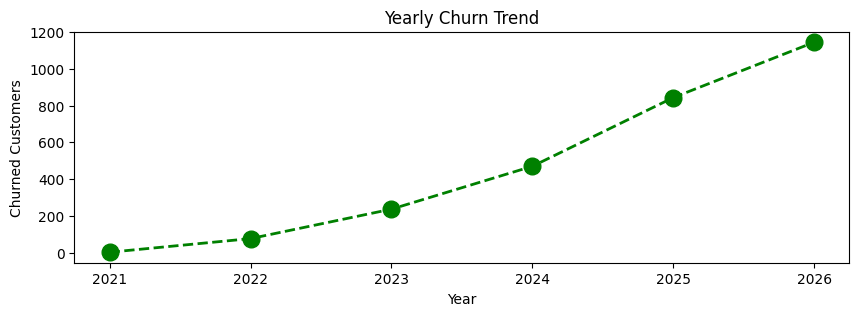

In [162]:
# 4.1 Yearly Churn Trend (Time Series KPI)

df_visual['cancellation_year'] = df_visual['cancellation_date'].dt.to_period('Y')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_year').size()

plt.figure(figsize=(10,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Yearly Churn Trend')
plt.xlabel('Year')
plt.ylabel('Churned Customers')
plt.show()

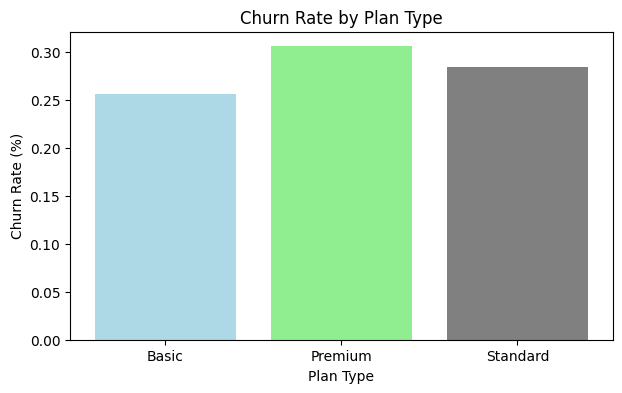

In [130]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['lightblue', 'lightgreen', 'grey']

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

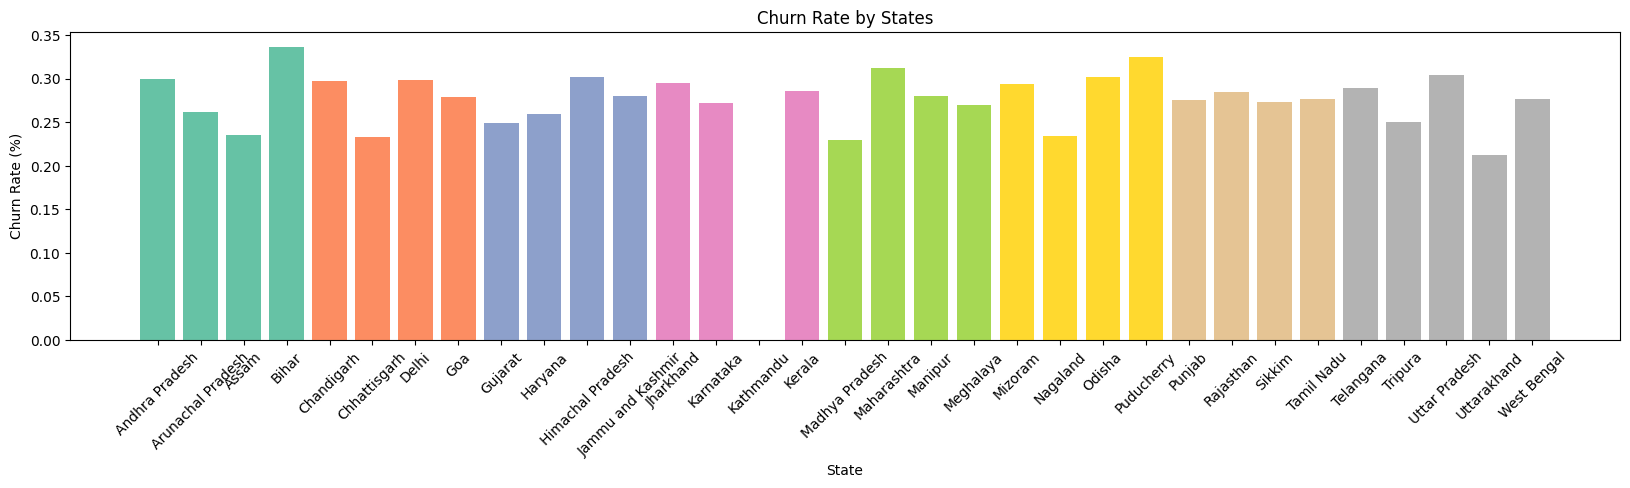

In [131]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(20,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by States')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [132]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk',
       'cancellation_year'],
      dtype='object')

In [133]:
df_visual.shape

(10000, 27)

In [135]:
df_visual.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,complaint_date,escalations,csat_score,is_escalated,complaint_count,tenure_days,age,churn_risk,is_high_risk,cancellation_year
0,0002-ORFBO,2021-03-15,Referral,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,NaT,0,NaN,NaN,NaN,2012.0,44,low,0,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,2024-08-28,0,10.0,1.0,2.0,1501.0,30,high,1,2024


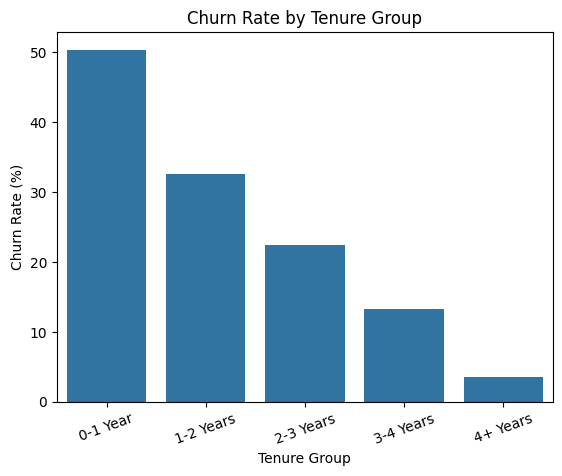

In [136]:
# 4.4 Churn rate by Tenure group
# Create tenure groups
df_visual['tenure_group'] = pd.cut(
    df_visual['tenure_days'],
    bins=[0, 365, 730, 1095, 1460, float('inf')],
    labels=['0-1 Year', '1-2 Years', '2-3 Years', '3-4 Years', '4+ Years']
)

# Churn rate
churn = df_visual.groupby('tenure_group', observed=True)['churn_flag'].mean() * 100

sns.barplot(x=churn.index, y=churn.values)

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.show()


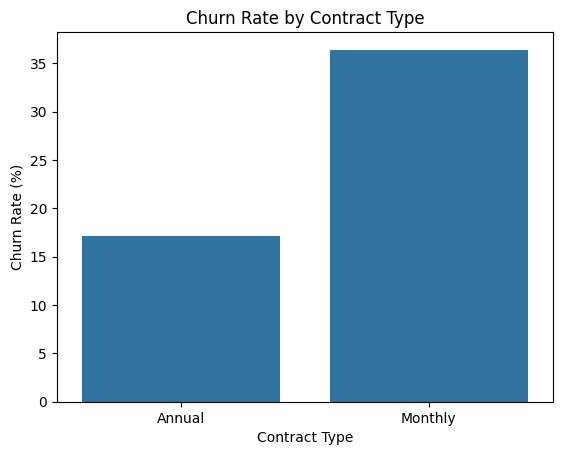

In [137]:
# 4.5 Churn rate by Contract type 
churn = df_visual.groupby('contract_type')['churn_flag'].mean() * 100

sns.barplot(x=churn.index, y=churn.values)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

In [138]:
df_visual['contract_type'].unique()

array(['Annual', 'Monthly'], dtype=object)

In [139]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'is_escalated',
       'complaint_count', 'tenure_days', 'age', 'churn_risk', 'is_high_risk',
       'cancellation_year', 'tenure_group'],
      dtype='object')

In [140]:
# Create age groups
df_visual['age_group'] = pd.cut(
    df_visual['age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '66-100'],
    include_lowest=True
)

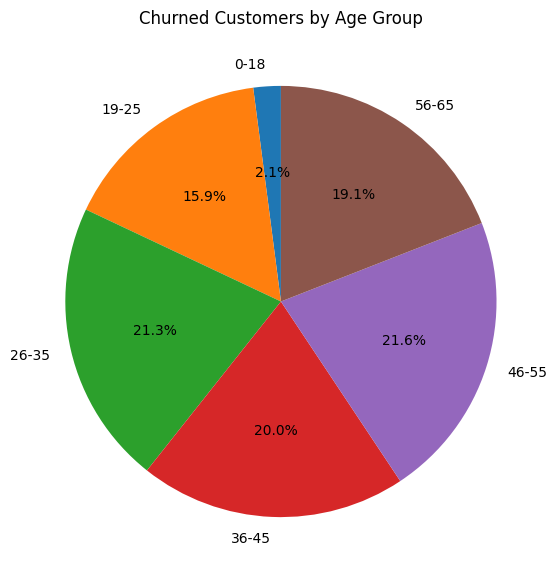

In [141]:
# 4.6 Churned Customers by Age Group

churned = (df_visual[df_visual['churn_flag'] == 1].groupby('age_group', observed=True)['customerid'].count())

plt.figure(figsize=(7, 7))

plt.pie(
    churned,
    labels=churned.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Churned Customers by Age Group')
plt.show()


In [184]:
# 4.7 # Heatmap (Correlation Matrix)
# encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'is_escalated']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

C:\Users\ADRIJ DAS\AppData\Local\Temp\ipykernel_11476\2257797114.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes
C:\Users\ADRIJ DAS\AppData\Local\Temp\ipykernel_11476\2257797114.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes
C:\Users\ADRIJ DAS\AppData\Local\Temp\ipykernel_11476\22577971

In [185]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'is_escalated']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,is_escalated
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,1.0
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,1.0


In [187]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,is_escalated
0,1,1,12,0,0,NaN
1,2,1,91,1,2,1.0
2,0,0,34,0,0,NaN
3,2,1,8,0,0,NaN
4,1,0,88,1,2,1.0


<Axes: >

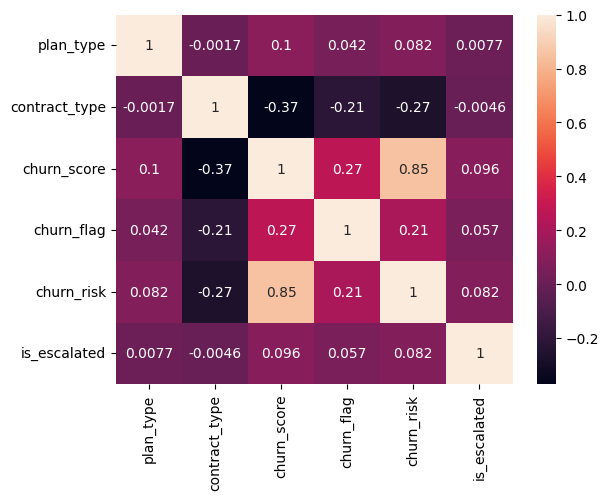

In [188]:
sns.heatmap(df_encoded.corr(), annot=True)

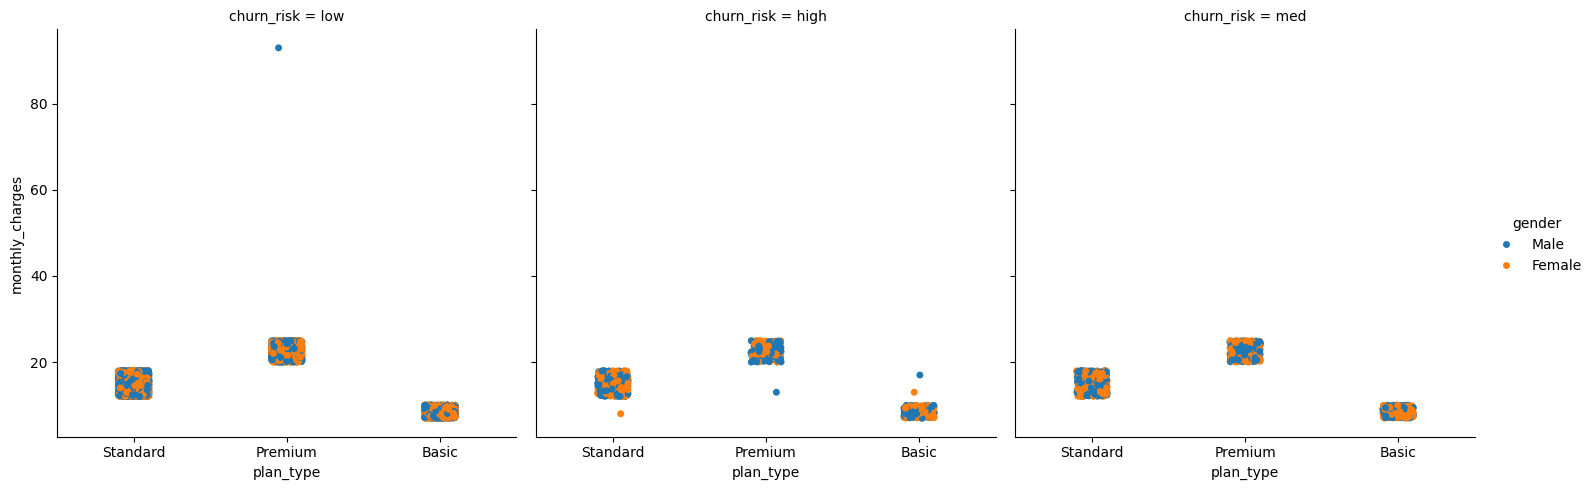

In [146]:
 # 4.8 catplt/Facegrid plot 

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

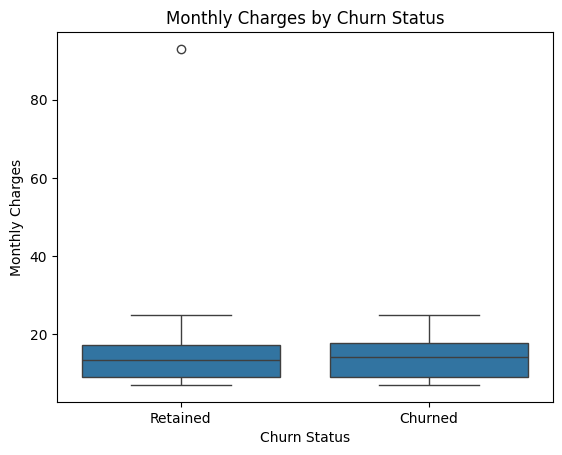

In [147]:
# 4.9 Monthly Charges by Churn Status
sns.boxplot(
    data=df_visual,
    x='churn_flag',
    y='monthly_charges'
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()

In [179]:
# 5.0 Churn Rate by Churn Risk
risk_analysis = (
    df_visual.groupby('churn_risk').agg(
        total_users=('customerid', 'count'),
        churned_users=('churn_flag', 'sum')
    ).reset_index()
)

risk_analysis['churn_rate'] = (
    risk_analysis['churned_users']
    / risk_analysis['total_users'] * 100
).round(2)

risk_analysis


,churn_risk,total_users,churned_users,churn_rate
0,high,886,462,52.14
1,low,7836,1800,22.97
2,med,1278,512,40.06


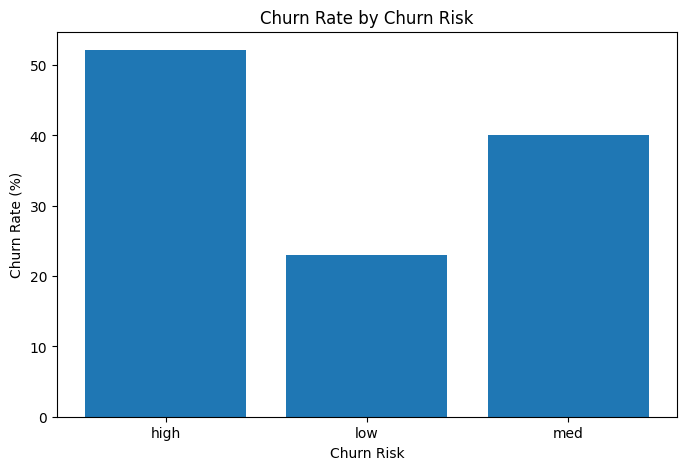

In [161]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_analysis['churn_risk'],
    risk_analysis['churn_rate']
)

plt.title('Churn Rate by Churn Risk')
plt.xlabel('Churn Risk')
plt.ylabel('Churn Rate (%)')
plt.show()

In [180]:
# 5.1 Average CLTV by Churn Status
cltv_analysis = (
    df_visual.groupby('churn_flag')['cltv']
    .mean()
    .round(2)
)

print(cltv_analysis)

churn_flag
0    464.22
1    249.75
Name: cltv, dtype: float64


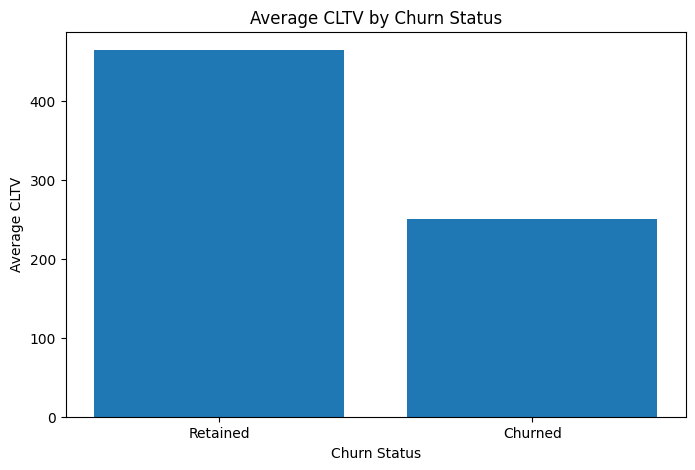

In [181]:
cltv_analysis = (
    df_visual.groupby('churn_flag')['cltv']
    .mean()
    .round(2)
)

plt.figure(figsize=(8, 5))

plt.bar(
    ['Retained', 'Churned'],
    cltv_analysis.values
)

plt.title('Average CLTV by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Average CLTV')
plt.show()

In [182]:
# 5.2 Cancellation Reason Analysis

reason_analysis = (
    df_visual[df_visual['churn_flag'] == 1]['cancellation_reason']
    .value_counts()
    .reset_index()
)

reason_analysis.columns = ['cancellation_reason', 'churned_users']

reason_analysis['percentage'] = (
    reason_analysis['churned_users']
    / reason_analysis['churned_users'].sum() * 100
).round(2)

reason_analysis

,cancellation_reason,churned_users,percentage
0,No longer interested,712,25.67
1,Too expensive,556,20.04
2,Poor content quality,411,14.82
3,Poor customer support,399,14.38
4,Switched to competitor,258,9.30
5,Personal reasons,219,7.89
6,Technical issues,216,7.79
7,Forgot to cancel trial,1,0.04
8,Not enough content,1,0.04
9,Poor streaming quality,1,0.04


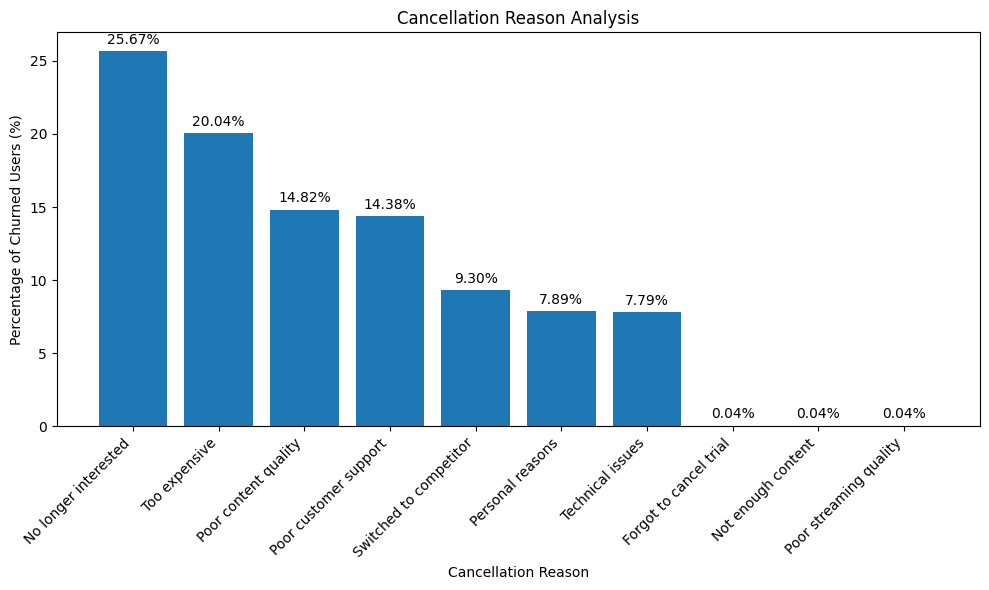

In [183]:
plt.figure(figsize=(10, 6))

plt.bar(
    reason_analysis['cancellation_reason'],
    reason_analysis['percentage']
)

plt.title('Cancellation Reason Analysis')
plt.xlabel('Cancellation Reason')
plt.ylabel('Percentage of Churned Users (%)')

plt.xticks(rotation=45, ha='right')

# Show percentage on bars
for i, value in enumerate(reason_analysis['percentage']):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center')

plt.tight_layout()
plt.show()


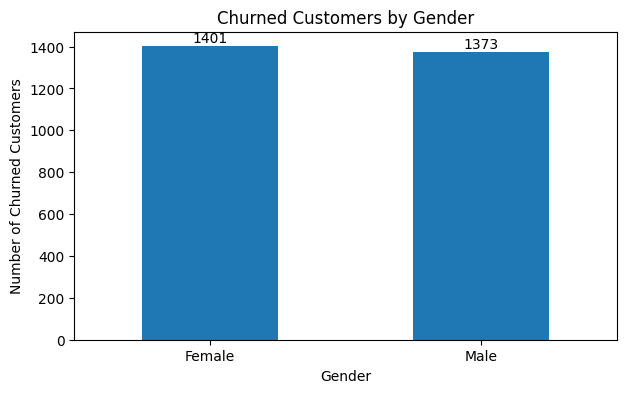

In [192]:
# 5.3 Churned Customer Count by Gender
gender_churn_count = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('gender')
    .size()
)

gender_churn_count.plot(
    kind='bar',
    figsize=(7, 4)
)

plt.title('Churned Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Churned Customers')
plt.xticks(rotation=0)

for i, v in enumerate(gender_churn_count):
    plt.text(i, v + 20, str(v), ha='center')

plt.show()

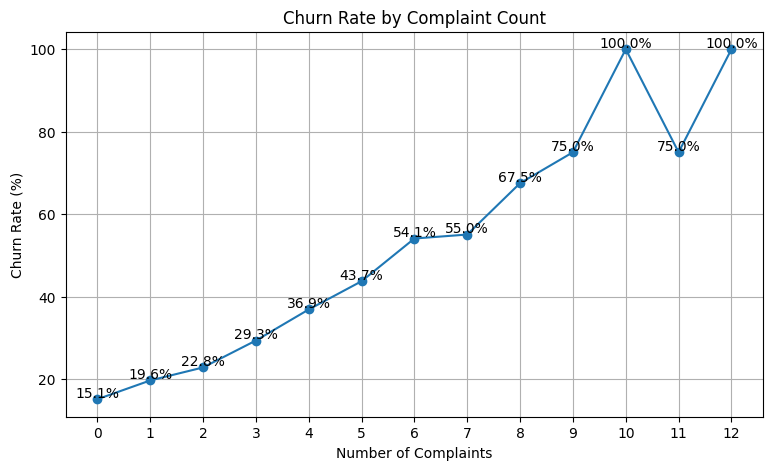

In [199]:
# customer-behaviour analysis-
# 5.4 Complaint Count vs Churn Rate

# Fill missing complaint counts with 0
df_visual['complaint_count'] = df_visual['complaint_count'].fillna(0)

# Complaint Count vs Churn Rate
complaint_churn = (
    df_visual.groupby('complaint_count')['churn_flag']
    .mean() * 100
)

complaint_churn.plot(
    kind='line',
    figsize=(9, 5),
    marker='o'
)

plt.title('Churn Rate by Complaint Count')
plt.xlabel('Number of Complaints')
plt.ylabel('Churn Rate (%)')
plt.xticks(complaint_churn.index)

for x, y in zip(complaint_churn.index, complaint_churn):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center')

plt.grid()
plt.show()

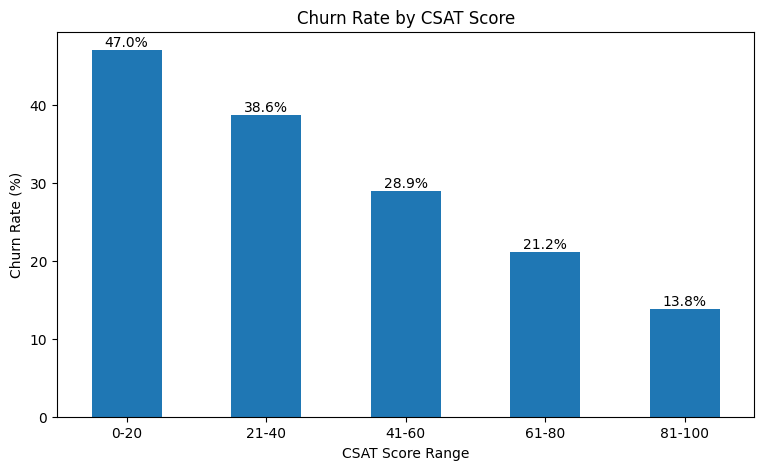

In [202]:
# 5.5 CSAT vs Churn Rate

# Create CSAT groups
df_visual['csat_group'] = pd.cut(
    df_visual['csat_score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100']
)

csat_churn = (
    df_visual.dropna(subset=['csat_score'])
    .groupby('csat_group', observed=True)['churn_flag']
    .mean() * 100
)

csat_churn.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Churn Rate by CSAT Score')
plt.xlabel('CSAT Score Range')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)

for i, v in enumerate(csat_churn):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.show()

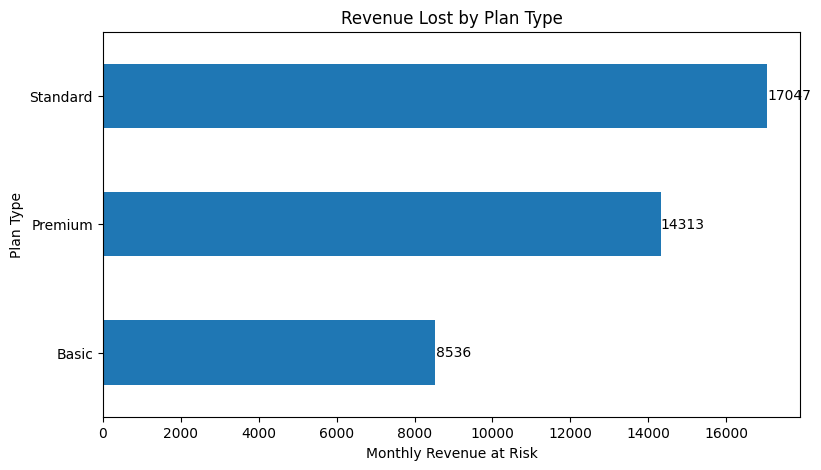

In [207]:
# 5.6 Revenue Lost by Plan Type
# Revenue Lost by Plan Type

revenue_lost_plan = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('plan_type')['monthly_charges']
    .sum()
    .sort_values()
)

revenue_lost_plan.plot(
    kind='barh',
    figsize=(9, 5)
)

plt.title('Revenue Lost by Plan Type')
plt.xlabel('Monthly Revenue at Risk')
plt.ylabel('Plan Type')

for i, v in enumerate(revenue_lost_plan):
    plt.text(v + 5, i, f'{v:.0f}', va='center')

plt.show()